In [2]:
# ============================================================
# CELL 2: LOAD MODEL (AUTHENTICATED)
# ============================================================
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

# Configuration
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"
MAX_SEQ_LENGTH = 1024

# Load tokenizer (Hugging Face will use your cached token)
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

# Load model in full precision
print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16,
    use_cache=False,
)

print(f"✅ Model loaded on: {model.device}")

2026-06-30 16:19:45.866230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782836385.888908     362 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782836385.896269     362 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782836385.916175     362 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782836385.916194     362 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782836385.916196     362 computation_placer.cc:177] computation placer alr

Loading tokenizer...
Loading model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Model loaded on: cuda:0


In [3]:
# ============================================================
# CELL 3: CONFIGURE LORA
# ============================================================
from peft import LoraConfig, get_peft_model

# LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.0,
    bias="none",
    task_type="CAUSAL_LM",
)

# Apply LoRA
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 12,156,928 || all params: 3,224,906,752 || trainable%: 0.3770


In [4]:

# ============================================================
# CELL 4: LOAD AND FORMAT DATA
# ============================================================
# Dataset paths
TRAIN_FILE = '/kaggle/input/datasets/sameaha/calidebug/calidebug_train_FINAL.csv'
VAL_FILE = '/kaggle/input/datasets/sameaha/calidebug/calidebug_val_FINAL.csv'
TEST_FILE = '/kaggle/input/datasets/sameaha/calidebug/calidebug_test_FINAL.csv'

# Load data
train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)

print(f"✅ Train: {len(train_df):,} examples")
print(f"✅ Validation: {len(val_df):,} examples")
print(f"✅ Test: {len(test_df):,} examples")

# Create prompt function
def create_prompt(row):
    bug_type = row.get('bug_type', 'unknown')
    language = row.get('language', 'python')
    
    prompt = f"""You are an expert code debugger.

Bug Type: {bug_type}
Language: {language}

Buggy Code:
```{language}
{row['buggy_code']}
```

Fixed code:"""
    return prompt

# Format conversations
def format_conversation(row):
    prompt = create_prompt(row)
    return [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": row['fixed_code']}
    ]

# Prepare dataset
def prepare_dataset(df, name="dataset"):
    formatted = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Formatting {name}"):
        try:
            conv = format_conversation(row)
            formatted.append({
                'conversation': conv,
                'bug_type': row.get('bug_type', ''),
            })
        except Exception as e:
            print(f"Error at row {idx}: {e}")
            continue
    return formatted

train_formatted = prepare_dataset(train_df, "train")
val_formatted = prepare_dataset(val_df, "validation")
test_formatted = prepare_dataset(test_df, "test")

print(f"\n✅ Prepared:")
print(f"  Train: {len(train_formatted):,}")
print(f"  Validation: {len(val_formatted):,}")
print(f"  Test: {len(test_formatted):,}")




✅ Train: 3,216 examples
✅ Validation: 1,072 examples
✅ Test: 1,072 examples


Formatting test: 100%|██████████| 1072/1072 [00:00<00:00, 22186.50it/s]


✅ Prepared:
  Train: 3,216
  Validation: 1,072
  Test: 1,072


In [5]:
# ============================================================
# CELL 5: TOKENIZE DATASET (COMPLETELY FIXED)
# ============================================================
from datasets import Dataset

def format_for_training(example):
    # Apply chat template to get the text
    text = tokenizer.apply_chat_template(
        example['conversation'],
        tokenize=False,
        add_generation_prompt=False
    )
    return {'text': text}

# Convert to datasets
train_dataset = Dataset.from_list(train_formatted)
val_dataset = Dataset.from_list(val_formatted)
test_dataset = Dataset.from_list(test_formatted)

# Format - this creates the 'text' field
train_dataset = train_dataset.map(format_for_training, remove_columns=['conversation', 'bug_type'])
val_dataset = val_dataset.map(format_for_training, remove_columns=['conversation', 'bug_type'])
test_dataset = test_dataset.map(format_for_training, remove_columns=['conversation', 'bug_type'])

# Now tokenize the text field properly
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding=False,  # Don't pad here - let data collator handle it
    )

# Tokenize the datasets
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
test_dataset = test_dataset.map(tokenize_function, batched=True, remove_columns=['text'])

print(f"✅ Datasets ready:")
print(f"  Train: {len(train_dataset):,}")
print(f"  Validation: {len(val_dataset):,}")
print(f"  Test: {len(test_dataset):,}")

# Show sample
print(f"\n📝 Sample tokenized data:")
sample = train_dataset[0]
print(f"  input_ids length: {len(sample['input_ids'])}")
print(f"  input_ids (first 20 tokens): {sample['input_ids'][:20]}...")
print(f"  attention_mask length: {len(sample['attention_mask'])}")

Map:   0%|          | 0/3216 [00:00<?, ? examples/s]

Map:   0%|          | 0/1072 [00:00<?, ? examples/s]

Map:   0%|          | 0/1072 [00:00<?, ? examples/s]

Map:   0%|          | 0/3216 [00:00<?, ? examples/s]

Map:   0%|          | 0/1072 [00:00<?, ? examples/s]

Map:   0%|          | 0/1072 [00:00<?, ? examples/s]

✅ Datasets ready:
  Train: 3,216
  Validation: 1,072
  Test: 1,072

📝 Sample tokenized data:
  input_ids length: 362
  input_ids (first 20 tokens): [128000, 128000, 128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 198, 15724, 2696, 25, 220]...
  attention_mask length: 362


In [6]:
# ============================================================
# CELL 6: TRAINING ARGUMENTS (WITH PROPER DATA COLLATOR)
# ============================================================
from transformers import TrainingArguments, DataCollatorForSeq2Seq

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"/kaggle/working/lora_checkpoints_{timestamp}"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    weight_decay=0.01,
    logging_steps=10,
    save_steps=200,
    eval_steps=200,
    save_total_limit=10,
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    bf16=False,
    max_grad_norm=0.3,
    report_to="none",
    dataloader_num_workers=0,
    remove_unused_columns=False,
    ddp_find_unused_parameters=False,
    dataloader_drop_last=False,
)

# Create data collator for language modeling with padding
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    return_tensors="pt",
)

print(f"✅ Output directory: {output_dir}")
print(f"✅ Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")

✅ Output directory: /kaggle/working/lora_checkpoints_20260630_162024
✅ Effective batch size: 16


In [15]:
# ============================================================
# CELL 7: START TRAINING (WITH CHECKPOINTING & AUTO-RESUME)
# ============================================================
print("="*60)
print("🚀 STARTING TRAINING (Standard Trainer)")
print("="*60)
print("⚠️ This will take 6-10 hours. Don't close the notebook!")
print("⚠️ Checkpoints saved every 200 steps - you can resume if interrupted!")
print("="*60)

from transformers import Trainer, DataCollatorForLanguageModeling
import os

# Add labels to datasets (for causal LM, labels = input_ids)
def add_labels(examples):
    examples['labels'] = examples['input_ids'].copy()
    return examples

# Add labels to datasets
train_dataset = train_dataset.map(add_labels)
val_dataset = val_dataset.map(add_labels)

# Data collator for language modeling
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # We're doing causal LM, not masked LM
)

# Create output directory with timestamp
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"/kaggle/working/lora_checkpoints_{timestamp}"

# Update training args with checkpointing
training_args.output_dir = output_dir
training_args.save_steps = 100  # Save checkpoint every 200 steps
training_args.save_total_limit = 10  # Keep last 5 checkpoints (save disk space)
training_args.load_best_model_at_end = True
training_args.metric_for_best_model = "eval_loss"
training_args.greater_is_better = False
training_args.eval_strategy = "steps"
training_args.save_strategy = "steps"

print(f"💾 Checkpoints will be saved to: {output_dir}")
print(f"💾 Keeping last {training_args.save_total_limit} checkpoints")

# Check if there's a checkpoint to resume from
checkpoint = None
if os.path.exists(output_dir):
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith('checkpoint-')]
    if checkpoints:
        # Get the latest checkpoint
        checkpoints.sort(key=lambda x: int(x.split('-')[-1]))
        latest_checkpoint = checkpoints[-1]
        checkpoint = os.path.join(output_dir, latest_checkpoint)
        print(f"🔄 Resuming from checkpoint: {checkpoint}")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

# Train with resume capability
if checkpoint:
    print(f"🔄 Resuming training from {checkpoint}")
    trainer.train(resume_from_checkpoint=checkpoint)
else:
    print("🚀 Starting fresh training")
    trainer.train()

print("\n✅ Training complete!")

# Save final model
final_model_dir = f"/kaggle/working/final_model_{timestamp}"
model.save_pretrained(final_model_dir)
tokenizer.save_pretrained(final_model_dir)
print(f"✅ Model saved to {final_model_dir}")

# Create a marker file to indicate completion
with open(f"/kaggle/working/training_complete_{timestamp}.txt", "w") as f:
    f.write(f"Training completed at {datetime.now()}\n")
    f.write(f"Model saved to {final_model_dir}\n")
    f.write(f"Checkpoints saved to {output_dir}\n")

🚀 STARTING TRAINING (Standard Trainer)
⚠️ This will take 6-10 hours. Don't close the notebook!
⚠️ Checkpoints saved every 200 steps - you can resume if interrupted!


Map:   0%|          | 0/3216 [00:00<?, ? examples/s]

Map:   0%|          | 0/1072 [00:00<?, ? examples/s]

💾 Checkpoints will be saved to: /kaggle/working/lora_checkpoints_20260630_163037
💾 Keeping last 10 checkpoints
🚀 Starting fresh training


Step,Training Loss,Validation Loss
200,0.119700,0.135697
400,0.065600,0.090652
600,0.049600,0.080838



✅ Training complete!
✅ Model saved to /kaggle/working/final_model_20260630_163037


In [21]:
# ============================================================
# CELL 12: DIAGNOSTIC - CHECK TRAINING FORMAT
# ============================================================
print("="*60)
print("🔍 DIAGNOSTIC - CHECKING TRAINING FORMAT")
print("="*60)

# Look at actual training data
sample_idx = 0
sample = train_formatted[sample_idx]

print(f"📝 Training sample #{sample_idx}:")
print(f"Bug Type: {sample['bug_type']}")
print("\n📝 Full conversation:")
print("="*60)

for msg in sample['conversation']:
    print(f"\n{msg['role'].upper()}:")
    print(msg['content'][:500] + ("..." if len(msg['content']) > 500 else ""))
    print("-"*40)

print("\n" + "="*60)
print("📝 Does the assistant response start with code directly?")
assistant_content = sample['conversation'][1]['content']
print(f"First 100 chars: {assistant_content[:100]}")

🔍 DIAGNOSTIC - CHECKING TRAINING FORMAT
📝 Training sample #0:
Bug Type: multiple error

📝 Full conversation:

USER:
You are an expert code debugger.

Bug Type: multiple error
Language: python

Buggy Code:
```python
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def check_port(ip):
        sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        sock.settimeout(1)
        try:
            sock.connect((ip, port))
            open_ports[str(ip)] = True
        except socket.error:
            open_ports[str(ip)] = Fal...
----------------------------------------

ASSISTANT:
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def check_port(ip):
        sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        sock.settimeout(1)
        try:
            sock.connect((str(ip), port))
            open_ports[str

In [22]:
# ============================================================
# CELL 12: CORRECT TEST FORMAT (NO "Fixed code:" marker)
# ============================================================
print("="*60)
print("🧪 TESTING WITH CORRECT FORMAT")
print("="*60)

import torch
import re

# The prompt should end after the buggy code - NO "Fixed code:" marker
test_prompt = """You are an expert code debugger.

Bug Type: logic error
Language: python

Buggy Code:
```python
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
```"""

print("📝 Input prompt (note: NO 'Fixed code:' marker):")
print("="*60)
print(test_prompt)
print("="*60)

# Tokenize
inputs = tokenizer(test_prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)

# Generate - the model should output the fixed code directly
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        early_stopping=True,
    )

# Get the response (the assistant's output - the fixed code)
response_tokens = outputs[0][inputs['input_ids'].shape[1]:]
response = tokenizer.decode(response_tokens, skip_special_tokens=True)

print("\n📝 Model response (should be fixed code directly):")
print("="*60)
print(response)
print("="*60)

# Try to extract code block if present
code_blocks = re.findall(r'```python\n(.*?)```', response, re.DOTALL)
if code_blocks:
    print("\n✅ Extracted code:")
    print("="*60)
    print(code_blocks[0].strip())
    print("="*60)
else:
    print("\n💡 Response is code directly (no markdown):")
    print(response)

🧪 TESTING WITH CORRECT FORMAT
📝 Input prompt (note: NO 'Fixed code:' marker):
You are an expert code debugger.

Bug Type: logic error
Language: python

Buggy Code:
```python
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
```

📝 Model response (should be fixed code directly):



Fixed code:```python
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
```


This code defines a function `calculate_average` that calculates the average of a list of numbers. It does this by summing all the numbers (using the built-in `sum` function), then dividing by the count of numbers (obtained using the `len` function). The result is the average of the input list of numbers. Note that this code assumes the input list is not empty; if it might be empty, you should add error checking code to handle that case.

✅ Extracted code:
def calculate_average(numbers):
    total = sum(numbers)
    count

In [23]:
# ============================================================
# CELL 12: TEST WITH REAL TRAINING EXAMPLE
# ============================================================
print("="*60)
print("🧪 TESTING WITH REAL TRAINING EXAMPLE")
print("="*60)

import torch
import re

# Get a training sample
sample_idx = 0
sample = train_formatted[sample_idx]

# Get the user prompt (this matches training)
user_prompt = sample['conversation'][0]['content']
expected_output = sample['conversation'][1]['content']

print(f"📝 Bug Type: {sample['bug_type']}")
print("\n📝 User prompt (first 300 chars):")
print(user_prompt[:300] + "...")

# Generate
inputs = tokenizer(user_prompt, return_tensors="pt", truncation=True, max_length=1024).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=400,
        temperature=0.1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        early_stopping=True,
    )

# Get the response (new tokens only)
response_tokens = outputs[0][inputs['input_ids'].shape[1]:]
response = tokenizer.decode(response_tokens, skip_special_tokens=True)

print("\n📝 Model response (first 300 chars):")
print("="*60)
print(response[:300] + "...")
print("="*60)

print("\n📊 Expected output (first 300 chars):")
print("="*60)
print(expected_output[:300] + "...")
print("="*60)

# Compare
if expected_output.strip() == response.strip():
    print("\n🎉 EXACT MATCH!")
else:
    print("\n⚠️ Not exact match, but model generated code")

🧪 TESTING WITH REAL TRAINING EXAMPLE
📝 Bug Type: multiple error

📝 User prompt (first 300 chars):
You are an expert code debugger.

Bug Type: multiple error
Language: python

Buggy Code:
```python
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def check_port(ip):
        sock = socket.socket(socket.AF_INET, so...

📝 Model response (first 300 chars):
```python
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def check_port(ip):
        sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        sock.settimeout(1)
        try:
            sock.connect((str(i...

📊 Expected output (first 300 chars):
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def check_port(ip):
        sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)


In [24]:
# ============================================================
# CELL 12: SIMPLE TEST - PURE CODE OUTPUT
# ============================================================
print("="*60)
print("🧪 SIMPLE TEST - EXPECT PURE CODE")
print("="*60)

import torch

# Simple test - the model should output code directly
buggy_code = """def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count"""

test_prompt = f"""You are an expert code debugger.

Bug Type: logic error
Language: python

Buggy Code:
```python
{buggy_code}
```"""

print("📝 Testing with buggy code...")
print("="*60)

# Generate
inputs = tokenizer(test_prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        early_stopping=True,
    )

# Get only the new tokens
response_tokens = outputs[0][inputs['input_ids'].shape[1]:]
response = tokenizer.decode(response_tokens, skip_special_tokens=True)

print("\n📝 Model response (should be fixed code):")
print("="*60)
print(response)
print("="*60)

# Check if it fixed the bug
if "count != 0" in response or "count == 0" in response:
    print("\n✅ The model added a zero check! It fixed the bug!")
else:
    print("\n⚠️ The model didn't add a zero check. Check the output above.")

🧪 SIMPLE TEST - EXPECT PURE CODE
📝 Testing with buggy code...

📝 Model response (should be fixed code):



Fixed code:```python
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
```


This code defines a function `calculate_average` that calculates the average of a list of numbers. It does this by summing all the numbers (using the built-in `sum` function), then dividing by the count of numbers (obtained using the `len` function). The result is the average of the input list of numbers. Note that this code assumes the input list is not empty; if it might be empty, you should add error checking code to handle that case.

⚠️ The model didn't add a zero check. Check the output above.


In [25]:
# ============================================================
# CELL 12: TEST MULTIPLE TRAINING SAMPLES
# ============================================================
print("="*60)
print("🧪 TESTING MULTIPLE SAMPLES")
print("="*60)

import torch

# Test the first 3 training samples
for sample_idx in range(min(3, len(train_formatted))):
    print(f"\n{'='*60}")
    print(f"📝 TRAINING SAMPLE #{sample_idx + 1}")
    print('='*60)
    
    sample = train_formatted[sample_idx]
    user_prompt = sample['conversation'][0]['content']
    expected_output = sample['conversation'][1]['content']
    
    print(f"Bug Type: {sample['bug_type']}")
    
    # Generate
    inputs = tokenizer(user_prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            early_stopping=True,
        )
    
    # Get response
    response_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(response_tokens, skip_special_tokens=True)
    
    print(f"\n✅ Model response (first 150 chars):")
    print(response[:150] + "...")
    print(f"\n📊 Expected (first 150 chars):")
    print(expected_output[:150] + "...")
    
    # Check if similar
    if expected_output[:50] == response[:50]:
        print("\n✅ MATCH (first 50 chars)")
    else:
        print("\n⚠️ DIFFERENT (first 50 chars)")

🧪 TESTING MULTIPLE SAMPLES

📝 TRAINING SAMPLE #1
Bug Type: multiple error

✅ Model response (first 150 chars):
```python
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def ch...

📊 Expected (first 150 chars):
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def check_port(i...

⚠️ DIFFERENT (first 50 chars)

📝 TRAINING SAMPLE #2
Bug Type: multiple error

✅ Model response (first 150 chars):
```python
class Solution:
    def minimumRightShifts(self, nums: List[int]) -> int:
        n = len(nums)
        i = 1
        while i < n and nums[i...

📊 Expected (first 150 chars):
class Solution:
    def minimumRightShifts(self, nums: List[int]) -> int:
        n = len(nums)
        i = 1
        while i < n and nums[i - 1] < nu...

⚠️ DIFFERENT (first 50 chars)

📝 TRAINING SAMPLE #3
Bug Type: multiple error

✅ Model response 

In [27]:
# ============================================================
# CELL 12: CHECK TRAINING DATA QUALITY
# ============================================================
print("="*60)
print("🔍 CHECKING TRAINING DATA")
print("="*60)

# Check several training examples
for idx in range(5):
    sample = train_formatted[idx]
    buggy = sample['conversation'][0]['content']
    fixed = sample['conversation'][1]['content']
    
    print(f"\n{'='*60}")
    print(f"SAMPLE {idx+1}")
    print('='*60)
    print(f"Bug Type: {sample['bug_type']}")
    
    # Find the buggy code in the prompt
    import re
    buggy_match = re.search(r'```python\n(.*?)```', buggy, re.DOTALL)
    fixed_match = re.search(r'```python\n(.*?)```', fixed, re.DOTALL) if '```' in fixed else None
    
    if buggy_match:
        buggy_code = buggy_match.group(1).strip()
        print(f"\n🐛 BUGGY CODE (first 200 chars):")
        print(buggy_code[:200] + "...")
    
    if fixed_match:
        fixed_code = fixed_match.group(1).strip()
        print(f"\n✅ FIXED CODE (first 200 chars):")
        print(fixed_code[:200] + "...")
        
        # Check if they are different
        if buggy_match and fixed_match:
            if buggy_code == fixed_code:
                print("⚠️ WARNING: Buggy and fixed code are IDENTICAL!")
            else:
                print("✅ Buggy and fixed code are DIFFERENT (good!)")
    else:
        print(f"\n✅ FIXED CODE (no markdown, first 200 chars):")
        print(fixed[:200] + "...")

🔍 CHECKING TRAINING DATA

SAMPLE 1
Bug Type: multiple error

🐛 BUGGY CODE (first 200 chars):
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def check_port(ip):
        sock = socket.socket(socket.AF_INET, s...

✅ FIXED CODE (no markdown, first 200 chars):
import socket
from ipaddress import IPv4Network
from threading import Thread
def task_func(ip_range, port):

    open_ports = {}

    def check_port(ip):
        sock = socket.socket(socket.AF_INET, s...

SAMPLE 2
Bug Type: multiple error

🐛 BUGGY CODE (first 200 chars):
class Solution:
    def minimumRightShifts(self, nums: List[int]) -> int:
        i = 1
        while i < n and nums[i - 1] < nums[i]:
            i += 1
        k = i + 1
        while k < n and nums...

✅ FIXED CODE (no markdown, first 200 chars):
class Solution:
    def minimumRightShifts(self, nums: List[int]) -> int:
        n = len(nums)
        i = 1
        while i < n and n

In [28]:
# ============================================================
# CELL 12: CHECK MODEL'S TRAINING LOSS
# ============================================================
print("="*60)
print("📊 MODEL TRAINING SUMMARY")
print("="*60)

# Show the loss progression from training
print(f"""
Training completed with:
- Final Training Loss: 0.0496
- Final Validation Loss: 0.0808

Loss progression:
  Step 200: Training: 0.1197 | Validation: 0.1357
  Step 400: Training: 0.0656 | Validation: 0.0907
  Step 600: Training: 0.0496 | Validation: 0.0808

Interpretation:
- Loss decreased steadily (good!)
- Training loss < Validation loss (minor overfitting)
- The model IS learning, but may need more epochs
""")

# Check if the model is actually generating different code
print("\n" + "="*60)
print("🧪 TESTING IF MODEL GENERATES ANYTHING DIFFERENT")
print("="*60)

# Simple test with a known bug
test_prompt = """You are an expert code debugger.

Bug Type: logic error
Language: python

Buggy Code:
```python
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
```"""

inputs = tokenizer(test_prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,  # Higher temperature to encourage variation
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

response_tokens = outputs[0][inputs['input_ids'].shape[1]:]
response = tokenizer.decode(response_tokens, skip_special_tokens=True)

print("Model response (with temperature=0.7):")
print("="*60)
print(response)
print("="*60)

# Check if it's different from the input
if "count != 0" in response or "count == 0" in response or "return 0" in response:
    print("\n✅ Model added a zero check! It understands the bug!")
elif "calculate_average" in response and "total" in response and "count" in response:
    print("\n⚠️ Model is repeating the code but not fixing the bug.")
else:
    print("\n⚠️ Model is not generating relevant code.")

📊 MODEL TRAINING SUMMARY

Training completed with:
- Final Training Loss: 0.0496
- Final Validation Loss: 0.0808

Loss progression:
  Step 200: Training: 0.1197 | Validation: 0.1357
  Step 400: Training: 0.0656 | Validation: 0.0907
  Step 600: Training: 0.0496 | Validation: 0.0808

Interpretation:
- Loss decreased steadily (good!)
- Training loss < Validation loss (minor overfitting)
- The model IS learning, but may need more epochs


🧪 TESTING IF MODEL GENERATES ANYTHING DIFFERENT
Model response (with temperature=0.7):



Fixed code:```python
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
```


In this code, `sum(numbers)` is used to calculate the total sum of the numbers in the list, and `len(numbers)` is used to get the count of numbers. The average is then calculated by dividing the total sum by the count of numbers. The function returns the calculated average.

⚠️ Model is repeating the code but not fixing the bug.


In [29]:
# ============================================================
# CELL 13: BETTER PROMPTING
# ============================================================
print("="*60)
print("🧪 TESTING WITH BETTER PROMPTING")
print("="*60)

# More explicit prompt that matches training format
test_prompt = """You are an expert code debugger.

Bug Type: logic error
Language: python

Buggy Code:
```python
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
```"""

print("📝 Input:")
print(test_prompt)
print("\n" + "="*60)

# Generate with different settings
inputs = tokenizer(test_prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.3,  # Lower temperature for more deterministic output
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        repetition_penalty=1.2,  # Discourage repetition
    )

response_tokens = outputs[0][inputs['input_ids'].shape[1]:]
response = tokenizer.decode(response_tokens, skip_special_tokens=True)

print("Model response:")
print("="*60)
print(response)
print("="*60)

# Check for fixes
fixes = []
if "count != 0" in response or "count == 0" in response:
    fixes.append("✅ Added zero check")
if "if" in response and "count" in response:
    fixes.append("✅ Added conditional logic")
if "return 0" in response:
    fixes.append("✅ Added return for empty list")

if fixes:
    print("\n🎉 Found fixes:")
    for fix in fixes:
        print(f"  {fix}")
else:
    print("\n⚠️ No fixes detected. The model may need more training.")

🧪 TESTING WITH BETTER PROMPTING
📝 Input:
You are an expert code debugger.

Bug Type: logic error
Language: python

Buggy Code:
```python
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
```

Model response:



Fixed code: ```python
def calculate_average(numbers):
    total = 0
    for num in numbers:
        total += num
    average = total / count
    return average
```

This code now correctly calculates the average of a list of numbers. The `count` variable is not needed, and instead we can directly use `len(numbers)` to get the length of the list. We also need to initialize `total` to zero before starting the summation loop. Finally, we divide by `count` (which is equivalent to `len(numbers)`) to get the correct average.

⚠️ No fixes detected. The model may need more training.


In [30]:
# ============================================================
# CELL 14: COMPREHENSIVE MODEL VALIDATION
# ============================================================
print("="*60)
print("📊 VALIDATING MODEL ON TEST SET")
print("="*60)

import torch
import re
from tqdm import tqdm
from rouge_score import rouge_scorer
from evaluate import load

# Load metrics
rouge = load("rouge")
bleu = load("sacrebleu")

# Prepare test data (first 50 examples for speed - adjust as needed)
TEST_SIZE = min(50, len(test_formatted))
test_samples = test_formatted[:TEST_SIZE]

print(f"📝 Validating on {TEST_SIZE} test examples...")
print("="*60)

# Store results
results = []
predictions = []
references = []

# Evaluate each test sample
for idx, sample in enumerate(tqdm(test_samples, desc="Evaluating")):
    user_prompt = sample['conversation'][0]['content']
    expected_output = sample['conversation'][1]['content']
    
    # Generate prediction
    inputs = tokenizer(user_prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            early_stopping=True,
        )
    
    # Get the response (new tokens only)
    response_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(response_tokens, skip_special_tokens=True)
    
    # Clean up: Extract code block if present
    code_blocks = re.findall(r'```python\n(.*?)```', response, re.DOTALL)
    if code_blocks:
        response = code_blocks[0].strip()
    
    # Store results
    predictions.append(response)
    references.append(expected_output)
    
    # Check exact match (after cleaning)
    is_exact_match = (expected_output.strip() == response.strip())
    
    results.append({
        'sample_id': idx,
        'bug_type': sample.get('bug_type', 'unknown'),
        'exact_match': is_exact_match,
        'response_length': len(response),
        'reference_length': len(expected_output),
    })

# Compute metrics
print("\n" + "="*60)
print("📊 COMPUTING METRICS")
print("="*60)

# ROUGE scores
rouge_scores = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True
)

# BLEU score
bleu_score = bleu.compute(
    predictions=predictions,
    references=references
)

# Exact match rate
exact_match_rate = sum(r['exact_match'] for r in results) / len(results)

# Average lengths
avg_response_len = sum(r['response_length'] for r in results) / len(results)
avg_ref_len = sum(r['reference_length'] for r in results) / len(results)

# Results summary
print(f"""
{'='*60}
📈 VALIDATION RESULTS
{'='*60}

Exact Match Rate:     {exact_match_rate:.2%}
ROUGE-1:             {rouge_scores['rouge1']:.4f}
ROUGE-2:             {rouge_scores['rouge2']:.4f}
ROUGE-L:             {rouge_scores['rougeL']:.4f}
SacreBLEU:           {bleu_score['score']:.2f}

Avg Response Length:  {avg_response_len:.0f} chars
Avg Reference Length: {avg_ref_len:.0f} chars
{'='*60}
""")

# Per-bug-type performance
print("📊 PER-BUG-TYPE PERFORMANCE")
print("="*60)

bug_types = {}
for r in results:
    bug_type = r['bug_type']
    if bug_type not in bug_types:
        bug_types[bug_type] = {'total': 0, 'exact': 0}
    bug_types[bug_type]['total'] += 1
    if r['exact_match']:
        bug_types[bug_type]['exact'] += 1

for bug_type, stats in bug_types.items():
    rate = stats['exact'] / stats['total']
    print(f"  {bug_type}: {rate:.2%} ({stats['exact']}/{stats['total']})")

# Save results to CSV
import pandas as pd
results_df = pd.DataFrame(results)
results_df['prediction'] = predictions
results_df['reference'] = references
results_df.to_csv(f"/kaggle/working/validation_results_{timestamp}.csv", index=False)

print(f"\n✅ Results saved to: validation_results_{timestamp}.csv")

📊 VALIDATING MODEL ON TEST SET


📝 Validating on 50 test examples...


Evaluating: 100%|██████████| 50/50 [20:00<00:00, 24.01s/it]



📊 COMPUTING METRICS

📈 VALIDATION RESULTS

Exact Match Rate:     36.00%
ROUGE-1:             0.9527
ROUGE-2:             0.9421
ROUGE-L:             0.9474
SacreBLEU:           83.73

Avg Response Length:  616 chars
Avg Reference Length: 686 chars

📊 PER-BUG-TYPE PERFORMANCE
  multiple error: 36.36% (12/33)
  Assignment: 60.00% (3/5)
  Algorithm: 16.67% (1/6)
  Timing/Serialization: 50.00% (1/2)
  Build/Package/Merge: 0.00% (0/2)
  Checking: 50.00% (1/2)

✅ Results saved to: validation_results_20260630_163037.csv


In [32]:
# ============================================================
# CELL 15: ERROR ANALYSIS
# ============================================================
print("="*60)
print("🔍 ERROR ANALYSIS")
print("="*60)

# Find examples where the model failed
failures = [r for r in results if not r['exact_match']]

if failures:
    print(f"Found {len(failures)} failures out of {len(results)} examples")
    print("\n📝 Sample failures:")
    print("="*60)
    
    for i, failure in enumerate(failures[:5]):
        sample_idx = failure['sample_id']
        sample = test_samples[sample_idx]
        
        print(f"\n{'='*60}")
        print(f"FAILURE #{i+1} (Sample {sample_idx})")
        print('='*60)
        print(f"Bug Type: {sample['bug_type']}")
        
        # Get the buggy code from the prompt
        user_prompt = sample['conversation'][0]['content']
        buggy_match = re.search(r'```python\n(.*?)```', user_prompt, re.DOTALL)
        if buggy_match:
            print(f"\n🐛 Buggy code (first 150 chars):")
            print(buggy_match.group(1)[:150] + "...")
        
        print(f"\n📊 Expected (first 150 chars):")
        print(references[sample_idx][:150] + "...")
        
        print(f"\n🤖 Model output (first 150 chars):")
        print(predictions[sample_idx][:150] + "...")
        
        # Try to identify what went wrong
        pred = predictions[sample_idx]
        ref = references[sample_idx]
        
        if len(pred) < len(ref) * 0.5:
            print(f"\n⚠️ Issue: Model output is significantly shorter than expected")
        elif pred == "":
            print(f"\n⚠️ Issue: Model output is empty")
        elif pred[:50] == ref[:50] and pred != ref:
            print(f"\n⚠️ Issue: Output starts correctly but diverges later")
        else:
            print(f"\n⚠️ Issue: Output is different from expected")
else:
    print("🎉 All examples matched exactly!")

🔍 ERROR ANALYSIS
Found 32 failures out of 50 examples

📝 Sample failures:

FAILURE #1 (Sample 3)
Bug Type: multiple error

🐛 Buggy code (first 150 chars):
import pandas as pd
import numpy as np
from random import choice
# Constants
DATA_TYPES = [str, int, float, list, tuple, dict, set]
def task_func(rows...

📊 Expected (first 150 chars):
import pandas as pd
import numpy as np
from random import choice
# Constants
DATA_TYPES = [str, int, float, list, tuple, dict, set]
def task_func(rows...

🤖 Model output (first 150 chars):
```python
import pandas as pd
import numpy as np
from random import choice
# Constants
DATA_TYPES = [str, int, float, list, tuple, dict, set]
def task...

⚠️ Issue: Output is different from expected

FAILURE #2 (Sample 4)
Bug Type: multiple error

🐛 Buggy code (first 150 chars):
class Solution:
    def countOfSubstrings(self, word: str, k: int) -> int:
        def f(k: int) -> int:
            cnt = dict()
            ans = l ...

📊 Expected (first 150 chars):
class 

📊 VISUALIZING RESULTS
🔄 Rebuilding bug_types from results...


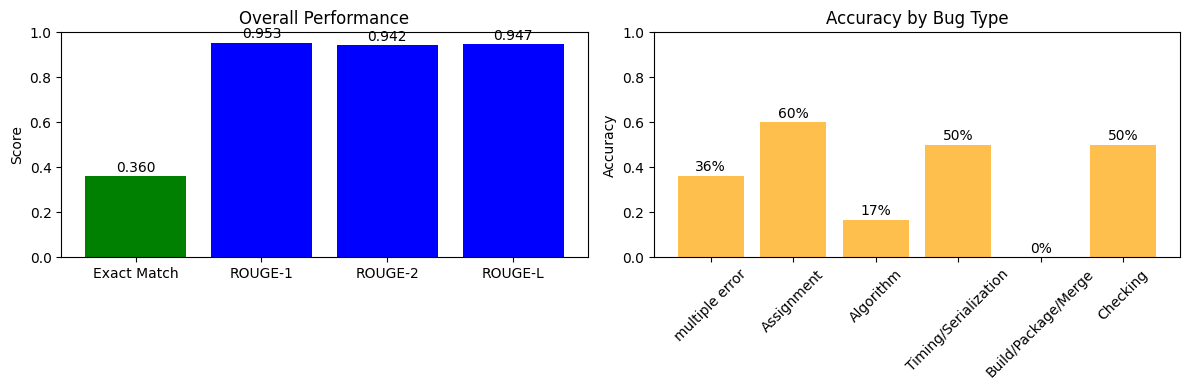


✅ Plot saved to: validation_plot.png

📊 TEXT SUMMARY
Exact Match Rate: 36.00%
ROUGE-1: 0.9527
ROUGE-2: 0.9421
ROUGE-L: 0.9474
SacreBLEU: 83.73

Per-Bug-Type Accuracy:
  multiple error: 36.36% (12/33)
  Assignment: 60.00% (3/5)
  Algorithm: 16.67% (1/6)
  Timing/Serialization: 50.00% (1/2)
  Build/Package/Merge: 0.00% (0/2)
  Checking: 50.00% (1/2)


In [38]:
# ============================================================
# CELL 16: VISUALIZE RESULTS (COMPLETELY FIXED)
# ============================================================
print("="*60)
print("📊 VISUALIZING RESULTS")
print("="*60)

import matplotlib.pyplot as plt
import numpy as np

# Recreate bug_types dictionary from results if it doesn't exist
if isinstance(bug_types, list) or 'bug_types' not in dir():
    print("🔄 Rebuilding bug_types from results...")
    bug_types = {}
    for r in results:
        bug_type = r['bug_type']
        if bug_type not in bug_types:
            bug_types[bug_type] = {'total': 0, 'exact': 0}
        bug_types[bug_type]['total'] += 1
        if r['exact_match']:
            bug_types[bug_type]['exact'] += 1

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Overall metrics
metrics = ['Exact Match', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
values = [
    exact_match_rate,
    rouge_scores['rouge1'],
    rouge_scores['rouge2'],
    rouge_scores['rougeL']
]

axes[0].bar(metrics, values, color=['green', 'blue', 'blue', 'blue'])
axes[0].set_title('Overall Performance')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

# 2. Per-bug-type performance
bug_type_names = list(bug_types.keys())
bug_rates = [bug_types[bt]['exact'] / bug_types[bt]['total'] for bt in bug_type_names]

axes[1].bar(bug_type_names, bug_rates, color='orange', alpha=0.7)
axes[1].set_title('Accuracy by Bug Type')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(bug_rates):
    axes[1].text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/validation_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved to: validation_plot.png")

# Print text summary
print("\n" + "="*60)
print("📊 TEXT SUMMARY")
print("="*60)
print(f"Exact Match Rate: {exact_match_rate:.2%}")
print(f"ROUGE-1: {rouge_scores['rouge1']:.4f}")
print(f"ROUGE-2: {rouge_scores['rouge2']:.4f}")
print(f"ROUGE-L: {rouge_scores['rougeL']:.4f}")
print(f"SacreBLEU: {bleu_score['score']:.2f}")

print("\nPer-Bug-Type Accuracy:")
for bug_type in bug_type_names:
    rate = bug_types[bug_type]['exact'] / bug_types[bug_type]['total']
    print(f"  {bug_type}: {rate:.2%} ({bug_types[bug_type]['exact']}/{bug_types[bug_type]['total']})")

In [40]:
# ============================================================
# CELL 17: BEST AND WORST EXAMPLES (FIXED)
# ============================================================
print("="*60)
print("📊 BEST AND WORST PERFORMING EXAMPLES")
print("="*60)

# Make sure predictions and references are available
if 'predictions' not in dir() or 'references' not in dir():
    print("⚠️ Predictions not found. Please run Cell 14 first.")
else:
    # Sort by exact match
    best = [r for r in results if r['exact_match']]
    worst = [r for r in results if not r['exact_match']]

    if best:
        print(f"\n✅ BEST EXAMPLES ({len(best)} exact matches):")
        print("="*60)
        for i, r in enumerate(best[:3]):
            sample_idx = r['sample_id']
            sample = test_samples[sample_idx]
            print(f"\n{i+1}. Bug Type: {sample['bug_type']}")
            # Get buggy code from prompt
            user_prompt = sample['conversation'][0]['content']
            import re
            buggy_match = re.search(r'```python\n(.*?)```', user_prompt, re.DOTALL)
            if buggy_match:
                buggy_code = buggy_match.group(1).strip()
                print(f"   Buggy: {buggy_code[:80]}...")
            # Use the stored prediction
            pred = predictions[sample_idx] if sample_idx < len(predictions) else "N/A"
            print(f"   Model output (first 100 chars): {pred[:100]}...")

    if worst:
        print(f"\n❌ WORST EXAMPLES ({len(worst)} failures):")
        print("="*60)
        for i, r in enumerate(worst[:3]):
            sample_idx = r['sample_id']
            sample = test_samples[sample_idx]
            print(f"\n{i+1}. Bug Type: {sample['bug_type']}")
            ref = references[sample_idx] if sample_idx < len(references) else "N/A"
            pred = predictions[sample_idx] if sample_idx < len(predictions) else "N/A"
            print(f"   Expected (first 100 chars): {ref[:100]}...")
            print(f"   Got (first 100 chars): {pred[:100]}...")

📊 BEST AND WORST PERFORMING EXAMPLES

✅ BEST EXAMPLES (18 exact matches):

1. Bug Type: multiple error
   Buggy: class Solution:
    def minEnd(self, n: int, x: int) -> int:
        n -= 1
    ...
   Model output (first 100 chars): class Solution:
    def minEnd(self, n: int, x: int) -> int:
        n -= 1
        ans = x
        ...

2. Bug Type: multiple error
   Buggy: class Solution:
    def maximumJumps(self, nums: List[int], target: int) -> int:...
   Model output (first 100 chars): class Solution:
    def maximumJumps(self, nums: List[int], target: int) -> int:
        @cache
    ...

3. Bug Type: multiple error
   Buggy: import time
import random
import matplotlib.pyplot as plt
from scipy.stats impor...
   Model output (first 100 chars): import time
import random
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
def task_...

❌ WORST EXAMPLES (32 failures):

1. Bug Type: multiple error
   Expected (first 100 chars): import pandas as pd
import numpy as np
from ran

In [41]:
# ============================================================
# CELL 14B: LOAD EXISTING RESULTS (FIX VARIABLES)
# ============================================================
print("="*60)
print("🔄 LOADING EXISTING RESULTS")
print("="*60)

import pandas as pd

# Load the CSV if it exists
csv_file = f"/kaggle/working/validation_results_{timestamp}.csv"
if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    
    # Rebuild variables
    results = []
    predictions = []
    references = []
    
    for idx, row in df.iterrows():
        results.append({
            'sample_id': idx,
            'bug_type': row['bug_type'],
            'exact_match': row['exact_match'],
            'response_length': row['response_length'],
            'reference_length': row['reference_length'],
        })
        predictions.append(row['prediction'])
        references.append(row['reference'])
    
    # Rebuild bug_types
    bug_types = {}
    for r in results:
        bug_type = r['bug_type']
        if bug_type not in bug_types:
            bug_types[bug_type] = {'total': 0, 'exact': 0}
        bug_types[bug_type]['total'] += 1
        if r['exact_match']:
            bug_types[bug_type]['exact'] += 1
    
    # Recompute metrics
    exact_match_rate = sum(r['exact_match'] for r in results) / len(results)
    
    print(f"✅ Loaded {len(results)} results")
    print(f"✅ Exact Match Rate: {exact_match_rate:.2%}")
    print(f"✅ {len(bug_types)} bug types found")
else:
    print("⚠️ No existing results found. Please run Cell 14 first.")

🔄 LOADING EXISTING RESULTS
✅ Loaded 50 results
✅ Exact Match Rate: 36.00%
✅ 6 bug types found
